In [205]:
# Carga de paquetes necesarios para graficar
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Para leer archivos
import geopandas as gpd # Para hacer cosas geográficas
import seaborn as sns # Para hacer plots lindos
import networkx as nx # Construcción de la red en NetworkX
import scipy

# Preambulo

En esta sección cargamos los datos y los visualizamos. También construimos la matriz de adyacencia de la red de museos.

## Carga de datos de los museos

El listado de los museos, con el que se construye el [mapa](https://mapas.museosabiertos.org/museos/caba/), lo podemos encontrar [acá](https://github.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/blob/principal/data/export.geojson?short_path=bc357f3). También descargamos los barrios de CABA como complemento para los gráficos.

In [206]:
# Leemos el archivo, retenemos aquellos museos que están en CABA, y descartamos aquellos que no tienen latitud y longitud
museos = gpd.read_file('https://raw.githubusercontent.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/refs/heads/principal/data/export.geojson')
barrios = gpd.read_file('https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson')

## Visualización

<Axes: >

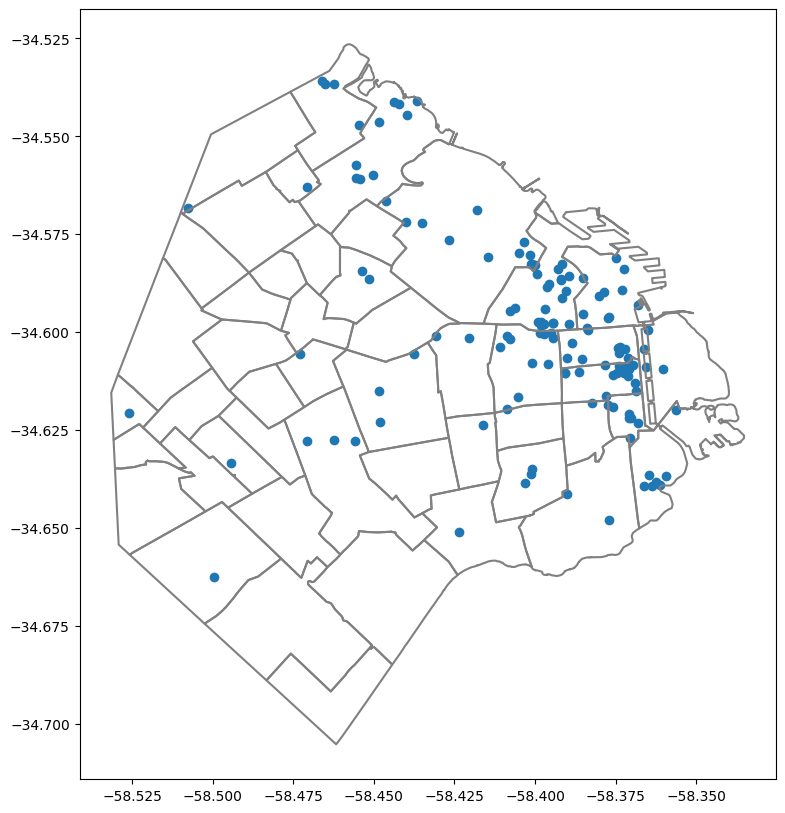

In [207]:
# Armamos el gráfico para visualizar los museos
fig, ax = plt.subplots(figsize=(10, 10))
barrios.boundary.plot(color='gray',ax=ax)
museos.plot(ax=ax)

## Cálculo de la matriz de distancias

Ahora construimos la matriz de distancias entre todos los museos. Como la tierra es un [geoide](https://es.wikipedia.org/wiki/Geoide) (es decir que no es [plana](https://es.wikipedia.org/wiki/Terraplanismo)), el cálculo de distancias no es una operación obvia. Una opción es proyectar a un [sistema de coordenadas local](https://geopandas.org/en/stable/docs/user_guide/projections.html), de forma tal que las distancias euclideas se correspondan con las distancias en metros. En este notebook usamos [EPSG](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset) 22184.

In [208]:
# En esta línea:
# Tomamos museos, lo convertimos al sistema de coordenadas de interés, extraemos su geometría (los puntos del mapa),
# calculamos sus distancias a los otros puntos de df, redondeamos (obteniendo distancia en metros), y lo convertimos a un array 2D de numpy
D = museos.to_crs("EPSG:22184").geometry.apply(lambda g: museos.to_crs("EPSG:22184").distance(g)).round().to_numpy()

### Matriz de adyacencia: construimos una matriz conectando a cada museo con los $m$ más cercanos

In [209]:
def construye_adyacencia(D,m):
    # Función que construye la matriz de adyacencia del grafo de museos
    # D matriz de distancias, m cantidad de links por nodo
    # Retorna la matriz de adyacencia como un numpy.
    D = D.copy()
    l = [] # Lista para guardar las filas
    for fila in D: # recorriendo las filas, anexamos vectores lógicos
        l.append(fila<=fila[np.argsort(fila)[m]] ) # En realidad, elegimos todos los nodos que estén a una distancia menor o igual a la del m-esimo más cercano
    A = np.asarray(l).astype(int) # Convertimos a entero
    np.fill_diagonal(A,0) # Borramos diagonal para eliminar autolinks
    return(A)

m = 3 # Cantidad de links por nodo
A = construye_adyacencia(D,m)

## Construcción de la red en NetworkX (sólo para las visualizaciones)

In [210]:
G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia
# Construimos un layout a partir de las coordenadas geográficas
G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

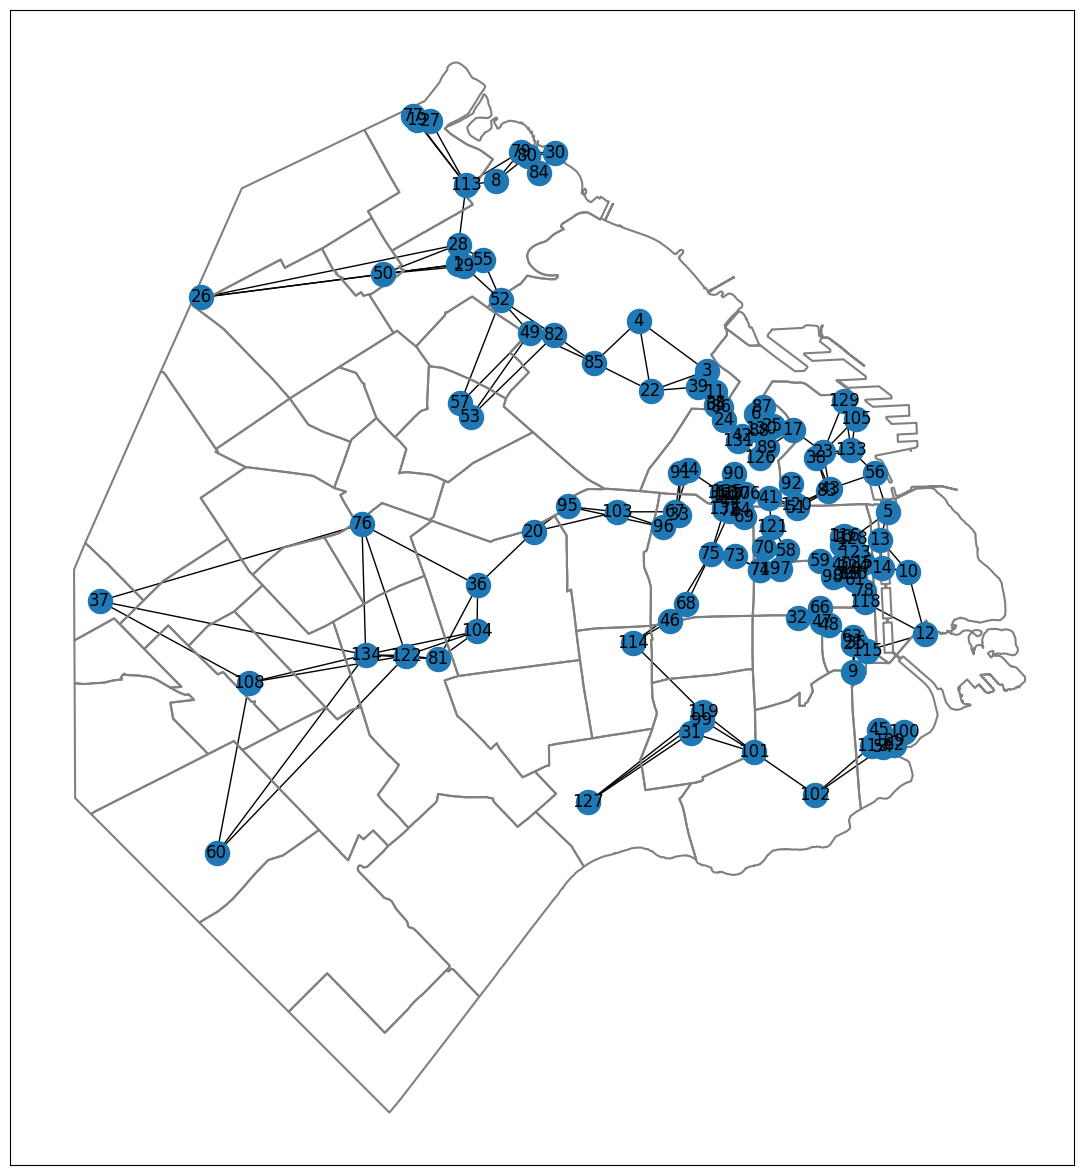

In [211]:
fig, ax = plt.subplots(figsize=(15, 15)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
nx.draw_networkx(G,G_layout,ax=ax) # Graficamos los museos

# Resolución del TP

Aquí empieza la aventura... ¡diviertanse y consulten lo que necesiten!

In [212]:
import template_funciones as template

## Punto 1:

###  Reescritura de la ecuación de PageRank como sistema lineal `Mp = b`

Partimos de la ecuación (3) del algoritmo de PageRank:

$$
p = (1 - \alpha) \cdot C \cdot p + \frac{\alpha}{N} \cdot \mathbf{1}
$$

donde:

$$
\begin{aligned}
p & \quad \text{es el vector de PageRank (una distribución de probabilidad)} \\
C & \quad \text{es la matriz de transiciones} \\
\alpha & \quad \text{es el factor de amortiguamiento (entre 0 y 1)} \\
\mathbf{1} & \quad \text{es un vector de unos de tamaño } N \\
N & \quad \text{es la cantidad total de museos (nodos)}
\end{aligned}
$$

---

#### Paso 1: Reorganizamos términos

Restamos el término `(1 - α)·C·p` del lado izquierdo:

$$
p - (1 - \alpha) \cdot C \cdot p = \frac{\alpha}{N} \cdot \mathbf{1}
$$

---

#### Paso 2: Sacamos factor común

$$
\left[ I - (1 - \alpha) \cdot C \right] \cdot p = \frac{\alpha}{N} \cdot \mathbf{1}
$$

---

#### Paso 3: Multiplicamos ambos lados por `N / α`

$$
\frac{N}{\alpha} \cdot \left[ I - (1 - \alpha) \cdot C \right] \cdot p = \mathbf{1}
$$

---

### Conclusión

Hemos llegado a un sistema lineal de la forma:

$$
M \cdot p = b
$$

donde:
- `M = (N / α) · (I - (1 - α) · C)`
- `b = 𝟏` (vector de unos)

Esta forma nos permite resolver el sistema con factorización LU, tal como se pide más adelante en el trabajo práctico.


## Punto 2:


Queremos analizar bajo qué condiciones el sistema:

$$
M \cdot p = b
$$

tiene una única solución.


Esto sucede si y solo si la matriz M es invertible.  
Cuando esto pasa, el determinante de M es distinto de cero:

$$
\det(M) \ne 0
$$

---
Recordamos que:

$$
M = \dfrac{N}{\alpha} \cdot \left( I - (1 - \alpha) \cdot C \right)
$$

donde:

- N es la cantidad de museos (tamaño de la matriz),
- $( \alpha )$ es un valor entre 0 y 1,
- C es la matriz de transiciones


-La matriz M está compuesta por un escalar positivo multiplicado por otra matriz


Como el escalar $\dfrac{N}{\alpha}$ es distinto de cero, basta con demostrar que:

$$
\det\left( I - (1 - \alpha) \cdot C \right) \ne 0
$$

---

Sabemos que:

- La matriz C es estocástica por columnas: sus entradas son no negativas y cada columna suma 1.
- Como 0 < $\alpha$ < 1, entonces (1 - $\alpha$) es un número positivo menor que 1.
- Al multiplicar C por (1 - $\alpha$), cada columna de la nueva matriz tiene suma menor que 1.
- Entonces, I menos esa matriz resulta en una matriz con diagonales positivas y dominante, con columnas linealmente independientes.

Por lo tanto:

$$
\det\left( I - (1 - \alpha) \cdot C \right) \ne 0
$$

---

### Conclusión

Como:

- $\left( I - (1 - \alpha) \cdot C \right)$ siempre tiene determinante distinto de cero,
- y el escalar $\dfrac{N}{\alpha}$ también es distinto de cero,

entonces:

$$
\det(M) \ne 0
$$

Por lo tanto, la matriz M es invertible y el sistema Mp = b tiene una única solución para cualquier valor de $( \alpha )$ entre 0 y 1.



## Punto 3:

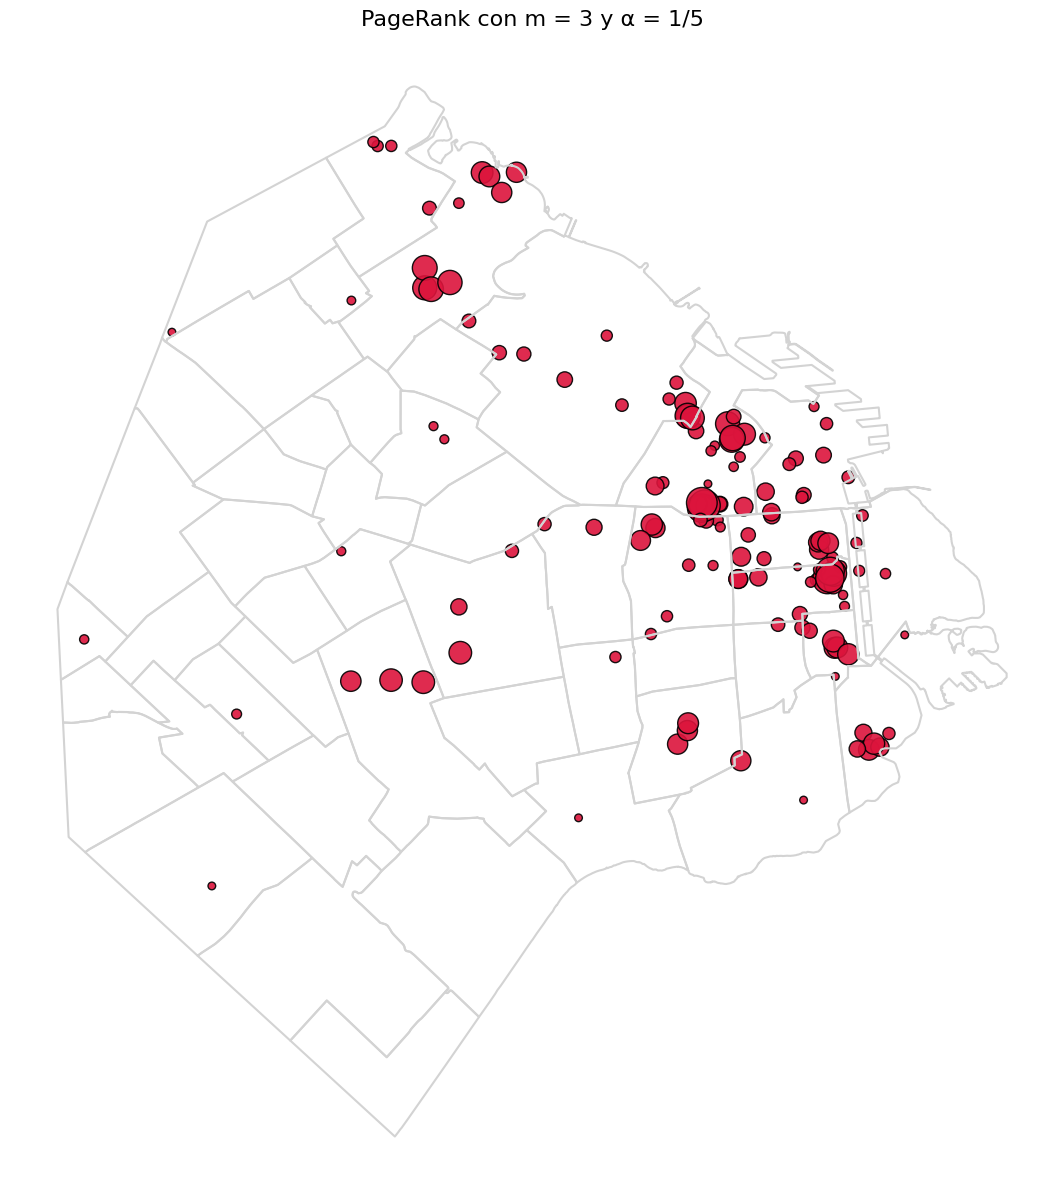

Top 3 museos según PageRank (m = 3, α = 1/5):
Museo 117 → PageRank: 0.024135
Museo 125 → PageRank: 0.023529
Museo 18 → PageRank: 0.021281


In [213]:
m = 3
alfa = 1/5

# Calculamos adyacencia y PageRank
A = template.construye_adyacencia(D, m)
p = template.calcula_pagerank(A, alfa)
museos["pagerank"] = p

# Normalizamos el PageRank para que los tamaños tengan mejor escala visual
pagerank_norm = museos["pagerank"] / museos["pagerank"].max()
tamaños = 500 * pagerank_norm

# Visualización
fig, ax = plt.subplots(figsize=(15, 15))
barrios.boundary.plot(color='lightgray', ax=ax)

museos.plot(
    ax=ax,
    markersize=tamaños,
    color="crimson",
    edgecolor="black",
    alpha=0.9
)

plt.title("PageRank con m = 3 y α = 1/5", fontsize=16)
plt.axis("off")
plt.show()

# Top 3 museos con mayor PageRank
top3_indices = np.argsort(p)[-3:][::-1]

print("Top 3 museos según PageRank (m = 3, α = 1/5):")
for idx in top3_indices:
    print(f"Museo {idx} → PageRank: {p[idx]:.6f}")

In [214]:
ms = [1, 3, 5, 10]
alfas = [6/7, 4/5, 2/3, 1/2, 1/3, 1/5, 1/7]
alfa_fijo = 1 / 5
m_fijo = 5


In [215]:
 #3b) calculamos pagerank para distintos m, con alfa fijo.

resultados_m = {}
top_museos_m = set()

for m in ms:
    A = template.construye_adyacencia(D, m)
    p = template.calcula_pagerank(A, alfa_fijo)
    resultados_m[m] = p
    top3 = np.argsort(p)[-3:]
    top_museos_m.update(top3)

In [216]:
# 3c calculamos pagerank con m fijo, para distintos alfa
resultados_alpha = {}
top_museos_alpha = set()

A = template.construye_adyacencia(D, m_fijo)
for alfa in alfas:
    p = template.calcula_pagerank(A, alfa)
    resultados_alpha[alfa] = p
    top3 = np.argsort(p)[-3:]
    top_museos_alpha.update(top3)





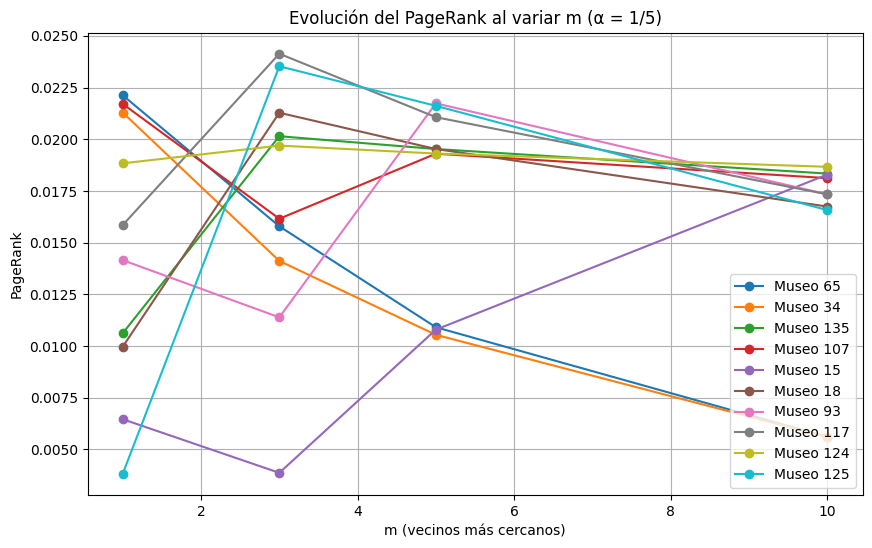

In [217]:
#grafico del pagerank al variar m
fig, ax = plt.subplots(figsize=(10, 6))
for idx in top_museos_m:
    valores = [resultados_m[m][idx] for m in ms]
    ax.plot(ms, valores, marker='o', label=f"Museo {idx}")
ax.set_title("Evolución del PageRank al variar m (α = 1/5)")
ax.set_xlabel("m (vecinos más cercanos)")
ax.set_ylabel("PageRank")
ax.legend()
ax.grid(True)
plt.show()


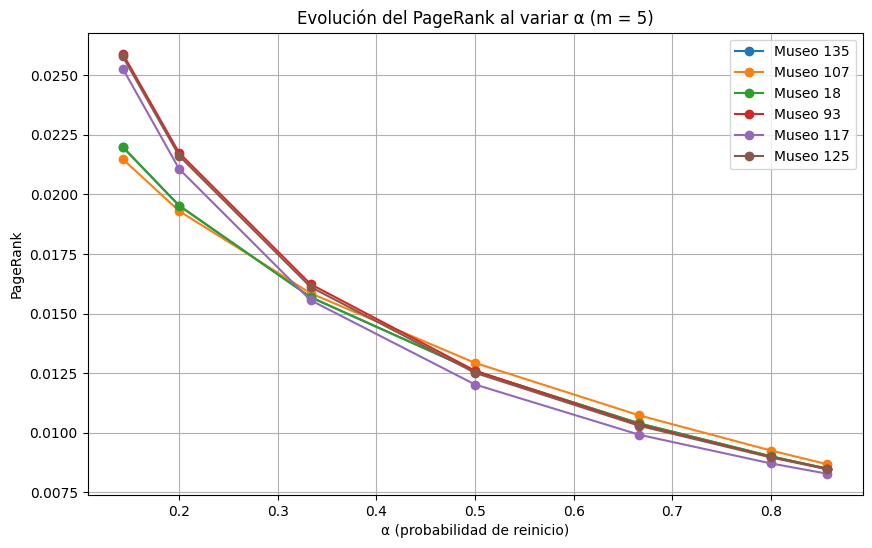

In [218]:
#grafico del pagerank al variar α
fig, ax = plt.subplots(figsize=(10, 6))
for idx in top_museos_alpha:
    valores = [resultados_alpha[a][idx] for a in alfas]
    ax.plot(alfas, valores, marker='o', label=f"Museo {idx}")
ax.set_title("Evolución del PageRank al variar α (m = 5)")
ax.set_xlabel("α (probabilidad de reinicio)")
ax.set_ylabel("PageRank")
ax.legend()
ax.grid(True)
plt.show()



## Análisis de la evolución del PageRank variando parámetros

### Evolución del PageRank al variar m (α = 1/5)

El gráfico 1 muestra cómo evoluciona el PageRank de los museos que estuvieron al menos una vez entre los tres más importantes, a medida que se modifica `m`, es decir, la cantidad de vecinos más cercanos con los que se conecta cada museo.

Algunos museos sólo aparecen en el top cuando m es chico. Por ejemplo, Museo 34 o Museo 65 tienen valores más altos solo con m bajos. Quizás son relevantes solo en redes muy locales.

-Otros museos se vuelven más relevantes en redes que se encuentran más conectadas, tales como el museo 15.

- En general, algunos museos mantienen un comportamiento estable (como el 124), esto puede indicar que son relevantes sin importar cuán conectada esté la red.

Podemos observar, que para valores de m chicos, entre `m = 1`y `m = 3`, hay muchos cruces de lineas. La red cambia mucho cuando la red está poco conectada. A partir de `m = 5`, el PageRank se estabiliza. Las curvas se ordenan y hay menos cambios en el top.


#### Conclusión:

- El valor de `m` afecta de forma importante el ranking de los museos.A medida que se incrementa m, la red se vuelve más conectada y el PageRank de los museos tiende a estabilizarse.
- Algunos museos son más relevantes en redes con pocas conexiones, mientras que otros escalan su importancia con redes más conectadas.


---

### Evolución del PageRank al variar α (m = 5)

El segundo gráfico muestra cómo varía el PageRank para los museos más importantes, manteniendo `m = 5` fijo, y modificando el parámetro α (probabilidad de reinicio aleatorio en el modelo de caminata aleatoria).

#### Observaciones:

- Todas las curvas muestran una disminución suave del PageRank a medida que aumenta α.
- Esto es coherente con la interpretación del modelo: cuanto mayor es α, mayor es la probabilidad de “teletransportarse” aleatoriamente a cualquier museo, y menor el peso que tiene la estructura de la red.
- **Museos como el 125 y el 93** comienzan con el valor de PageRank más alto cuando α es bajo (por ejemplo, 1/7), y pierden esa ventaja progresivamente a medida que α aumenta.
- Las curvas de los distintos museos tienden a acercarse cuando α es alto (como 6/7), lo cual indica que la **distribución se vuelve más uniforme**.

#### Conclusión:
α regula cuánto importa la estructura de la red. Mientras más alto es α, la caminata se vuelve más aleatoria, y el PageRank se distribuye más parejo entre todos.



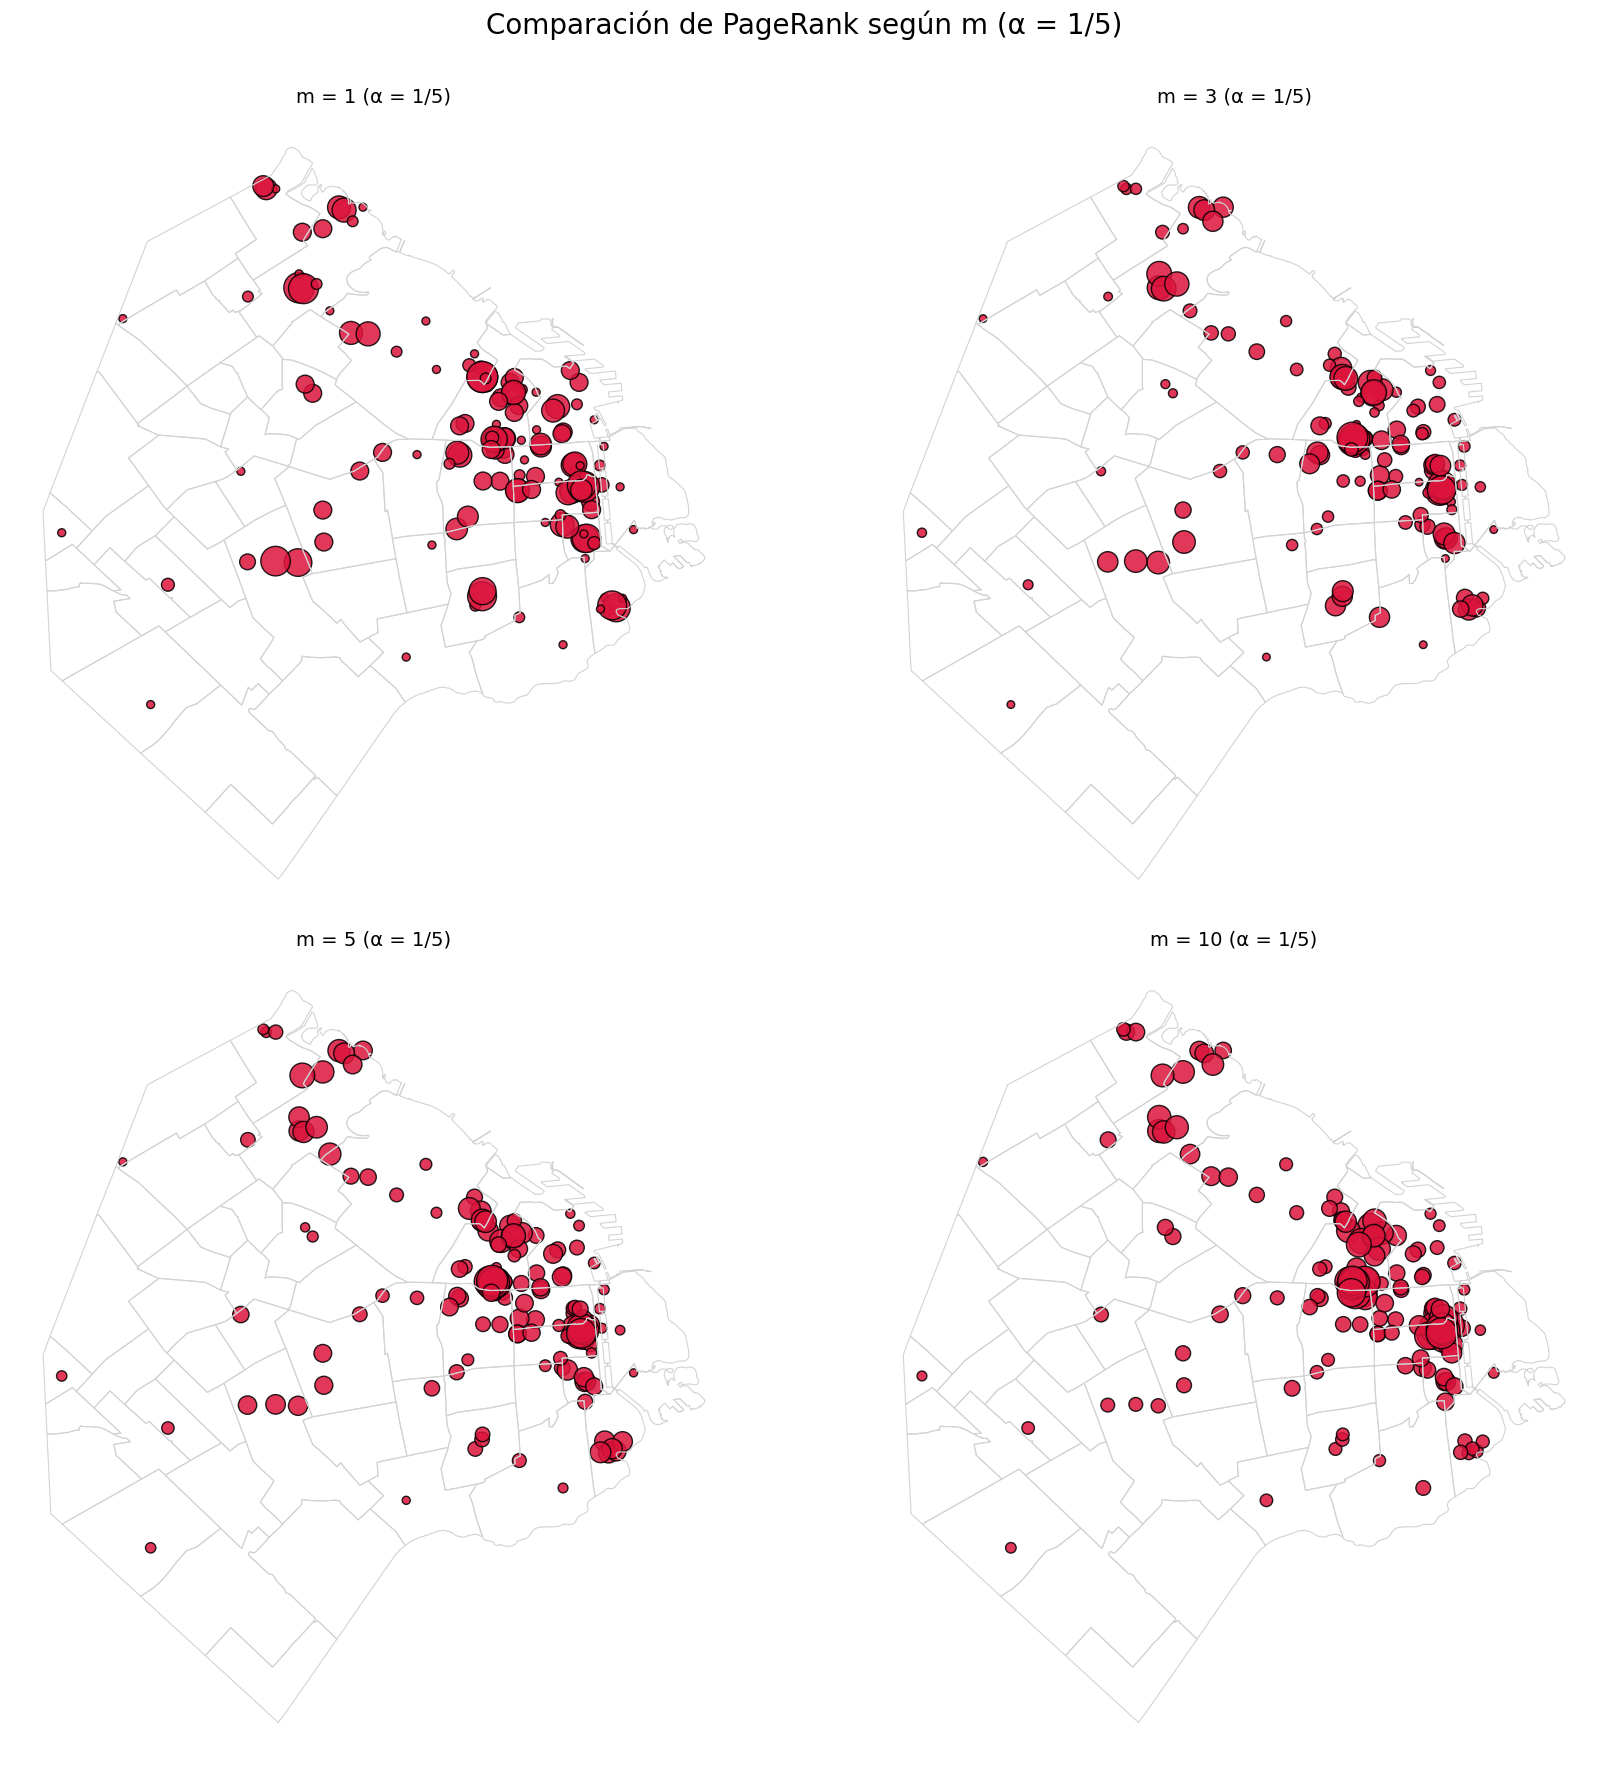

In [219]:
#Mapa con los pageranks para distintos m
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

for idx, m in enumerate(ms):
    ax = axes[idx // 2, idx % 2]
    p = resultados_m[m]
    museos["pagerank"] = p

    pagerank_norm = p / p.max()
    sizes = 500 * pagerank_norm

    barrios.boundary.plot(ax=ax, color='lightgray', linewidth=0.8)
    museos.plot(
        ax=ax,
        markersize=sizes,
        alpha=0.85,
        edgecolor="black",
        color="crimson"
    )

    ax.set_title(f"m = {m} (α = 1/5)", fontsize=14)
    ax.axis("off")

plt.suptitle("Comparación de PageRank según m (α = 1/5)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


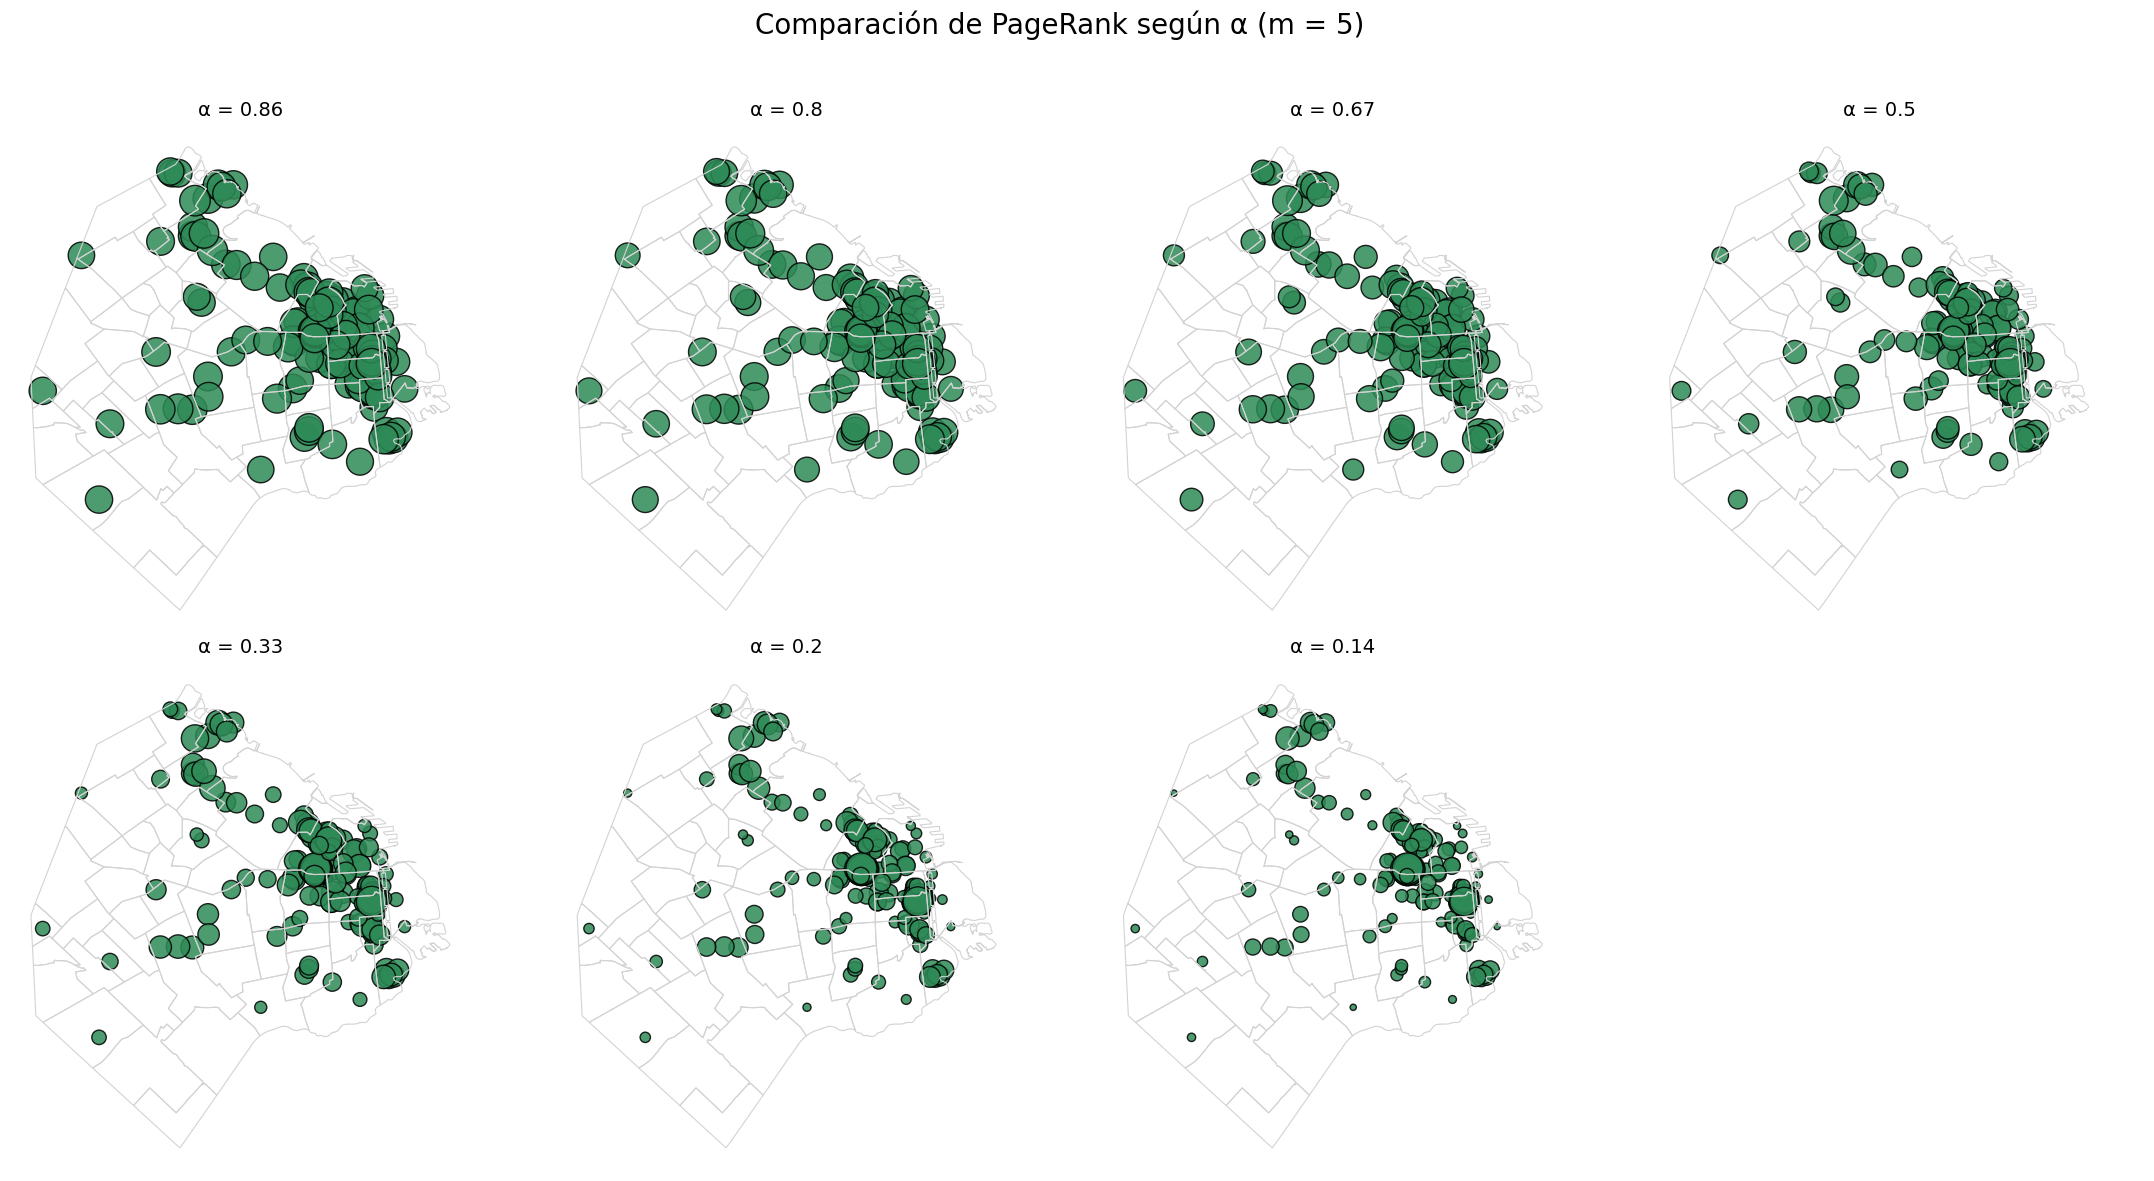

In [220]:
#mapa con los pageranks para distintos alfa
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for idx, alfa in enumerate(alfas):
    ax = axes[idx]
    p = resultados_alpha[alfa]
    museos["pagerank"] = p

    pagerank_norm = p / p.max()
    sizes = 500 * pagerank_norm

    barrios.boundary.plot(ax=ax, color='lightgray', linewidth=0.8)
    museos.plot(
        ax=ax,
        markersize=sizes,
        alpha=0.85,
        edgecolor="black",
        color="seagreen"
    )

    ax.set_title(f"α = {round(alfa, 2)}", fontsize=14)
    ax.axis("off")

# Apagar último subplot vacío (8 espacios, 7 alfas)
if len(alfas) < len(axes):
    axes[-1].axis("off")

plt.suptitle("Comparación de PageRank según α (m = 5)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Análisis visual de los mapas de PageRank

Los mapas muestran cómo se distribuye el pagerank de los museo de Buenos Aires, según los parámetros `m`  y `α`.

### Mapas según m (α = 1/5)


A medida que aumenta `m`, es decir, cuántos vecinos cercanos tiene cada museo en la red, se observan patrones claros:

- Con `m = 1`, hay pocos nodos grandes y muchos puntos muy chicos o invisibles. La red es poco conectada y el PageRank se concentra en museos puntuales

- En `m = 3`, más nodos empiezan a participar y se reduce la desigualdad. Aun así, sigue habiendo diferencias notables entre los museos.

- Con `m = 5`, aparece una distribución más equilibrada, pero sin que todos los museos sean iguales. Hay una presencia destacada en zonas céntricas y norte.

- En `m = 10`, la mayoría de los nodos tienen al menos algún nivel de visibilidad. Aun así, persisten núcleos relevantes, especialmente en el centro, que siguen concentrando gran parte del PageRank.

**Conclusión**: aumentar `m` no aplana completamente el PageRank, pero sí permite que más museos tengan visibilidad. Las diferencias extremas se reducen y emergen patrones regionales más claros. El centro y norte de la ciudad mantienen su centralidad incluso cuando la red es muy densa.

---

###  Mapas según α (m = 5)

- Con α alto (0.86, 0.8), los puntos son bastante uniformes, la aleatoriedad domina y las diferencias entre museos se achican.
- A medida que α baja (0.33, 0.2, 0.14), algunos museos ganan mucha más relevancia.
- Se observa una mayor concentración de museos importantes en la zona norte y centro, cuando α es bajo.

**Conclusión**:  A mayor α, todos los nodos se parecen más.Tal como se había visualizado en el gráfico, el pagerank se distribuye más parejo.

---

 En conjunto con los gráficos de líneas, estos mapas permiten ver **no sólo qué museos son importantes**, sino **dónde están ubicados** y cómo su importancia varía en el espacio y bajo diferentes parámetros.


## Punto 4:


Queremos demostrar que si:

- `w` es el vector que contiene el **número total de visitas** que recibió cada museo,
- cada persona realiza exactamente `r` visitas durante la Noche de los Museos,
- y `v` es el vector que indica cuántas personas comenzaron su recorrido en cada museo,

entonces se cumple la relación:

$$
w = B \cdot v \quad \text{donde} \quad B = I + C + C^2 + \dots + C^{r-1}
$$

y, por lo tanto:

$$
v = B^{-1} \cdot w
$$

---

- $C$ es la **matriz de transiciones**, donde cada entrada $C_{ij}$ indica la probabilidad de ir del museo $j$ al museo $i$ en un paso.
- $C^k \cdot v$ representa la distribución de visitantes en los museos **luego de $k$ pasos**, asumiendo que comenzaron con distribución $v$.

Entonces:

- En el paso 0, la distribución es $v$
- En el paso 1, es $C \cdot v$
- En el paso 2, es $C^2 \cdot v$
- ...
- En el paso $r - 1$, es $C^{r-1} \cdot v$

---

### Suma total de visitas

Si cada persona visita un museo en cada uno de los $r$ pasos, el **número total de visitas a cada museo** se calcula sumando todas las distribuciones:

$$
w = v + C \cdot v + C^2 \cdot v + \dots + C^{r-1} \cdot v
$$

Sacando factor común:

$$
w = \left( I + C + C^2 + \dots + C^{r-1} \right) \cdot v = B \cdot v
$$

---

### Conclusión

Hemos demostrado que:

$$
w = B \cdot v \quad \Rightarrow \quad v = B^{-1} \cdot w
$$

Esto permite calcular la cantidad de personas que comenzaron en cada museo, a partir de los datos observados de visitas totales $w$.


## Punto 5:

In [ ]:
C = template.calcula_matriz_C_continua(D)
r = 3
B = template.calcula_B(C, r)
w = np.loadtxt("visitas.txt")
L, U = template.calculaLU(B)
y = solve_triangular(L, w, lower=True)  # Ly = w
v = solve_triangular(U, y)              # Uv = y
print("Norma 1 de v (cantidad total de visitantes que ingresaron):", np.sum(np.abs(v)))


## Punto 6:

In [ ]:
# Calculamos el número de condición
cond_B = condicion_1_por_LU(B)
print("Número de condición en norma 1:", cond_B)

# Cota del error relativo de v
error_w_relativo = 0.05
cota_error_v = cond_B * error_w_relativo
print("Cota para el error relativo en v:", cota_error_v)


# Extras

Para graficar la red con un conjunto de puntajes (como el Page Rank)

{0: Text(4924405.086723215, 6160838.106023658, '0'),
 1: Text(4917216.80489522, 6166701.553530234, ''),
 2: Text(4924486.298584606, 6161409.256658559, ''),
 3: Text(4921922.052887296, 6164690.544542129, ''),
 4: Text(4920636.67547965, 6165640.199444978, ''),
 5: Text(4925338.320928778, 6162016.528710163, ''),
 6: Text(4922856.100832731, 6163868.567721188, ''),
 7: Text(4922641.894255253, 6162355.100129171, ''),
 8: Text(4917938.7521918025, 6168273.372961773, ''),
 9: Text(4924683.52693892, 6158996.617208998, ''),
 10: Text(4925725.9600755945, 6160896.846339954, ''),
 11: Text(4922075.10183836, 6164294.738410278, ''),
 12: Text(4926038.146946977, 6159721.190876993, '12'),
 13: Text(4925200.592014585, 6161503.005610317, ''),
 14: Text(4925229.168803978, 6160973.145341254, ''),
 15: Text(4924875.410406244, 6161061.981187101, ''),
 16: Text(4924474.294424794, 6161547.549492302, ''),
 17: Text(4923553.755484842, 6163571.336254905, ''),
 18: Text(4924615.955668659, 6160843.2491330765, ''),
 

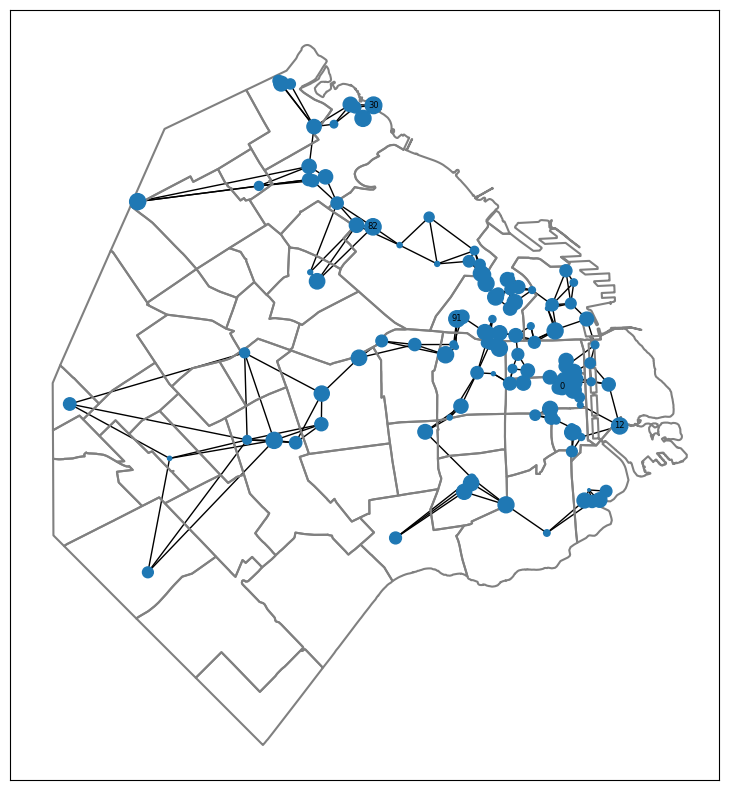

In [223]:
factor_escala = 1e4 # Escalamos los nodos 10 mil veces para que sean bien visibles
fig, ax = plt.subplots(figsize=(10, 10)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
pr = np.random.uniform(0,1,museos.shape[0])# Este va a ser su score Page Rank. Ahora lo reemplazamos con un vector al azar
pr = pr/pr.sum() # Normalizamos para que sume 1
Nprincipales = 5 # Cantidad de principales
principales = np.argsort(pr)[-Nprincipales:] # Identificamos a los N principales
labels = {n: str(n) if i in principales else "" for i, n in enumerate(G.nodes)} # Nombres para esos nodos
nx.draw_networkx(G,G_layout,node_size = pr*factor_escala, ax=ax,with_labels=False) # Graficamos red
nx.draw_networkx_labels(G, G_layout, labels=labels, font_size=6, font_color="k") # Agregamos los nombres